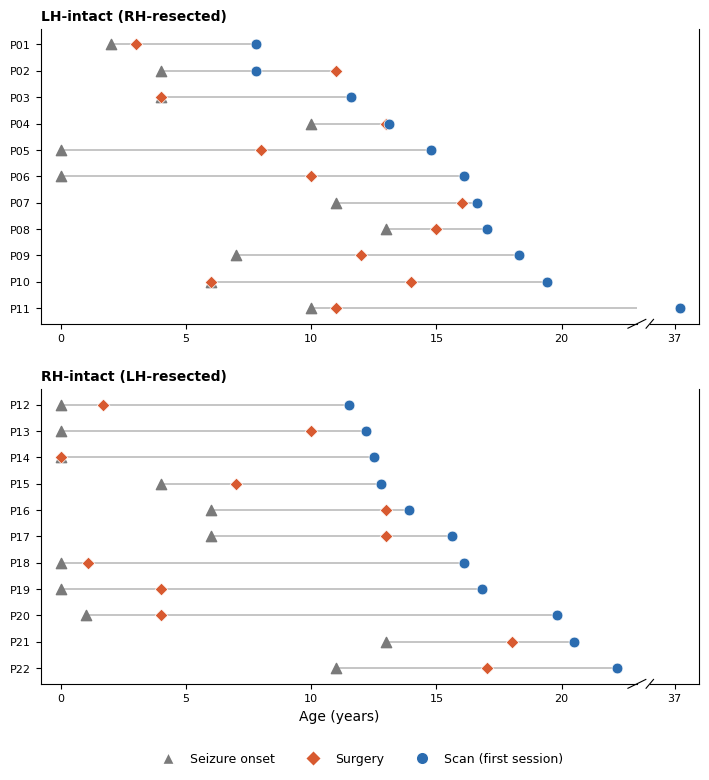

In [2]:
#!/usr/bin/env python
"""
Patient clinical timeline figure (Liu-style, on a real age axis).
Two panels: LH-intact (RH-resected) and RH-intact (LH-resected).
Markers: seizure onset (triangle), surgery (diamond), scan (circle = first session).
Broken x-axis to accommodate sub-091 (scan age 37.3).
Edit the LH/RH lists to adjust values; nothing is auto-derived.
"""
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---- data: (label, seizure_y, surgery_y, scan_y) ----
# None = not available / not plotted. scan_y = first-session scan age.
LH = [  # LH-intact, sorted by scan age
    ("P01",  2.0,  3.0,  7.8),
    ("P02",  4.0, 11.0,  7.8),
    ("P03",  4.0,  4.0, 11.6),
    ("P04", 10.0, 13.0, 13.1),
    ("P05",  0.0,  8.0, 14.8),
    ("P06",  0.0, 10.0, 16.1),
    ("P07", 11.0, 16.0, 16.6),
    ("P08", 13.0, 15.0, 17.0),
    ("P09",  7.0, 12.0, 18.3),
    ("P10",  6.0, (6.0, 14.0), 19.4),
    ("P11", 10.0, 11.0, 37.3),
]
RH = [  # RH-intact, sorted by scan age
    ("P12",  0.0,  1.7, 11.5),
    ("P13",  0.0, 10.0, 12.2),
    ("P14",  0.0,  0.0, 12.5),   # surgery = 1 day -> plotted at 0, labeled "1d"
    ("P15",  4.0,  7.0, 12.8),
    ("P16",  6.0, 13.0, 13.9),
    ("P17",  6.0, 13.0, 15.6),
    ("P18",  0.0,  1.1, 16.1),
    ("P19",  0.0,  4.0, 16.8),
    ("P20",  1.0,  4.0, 19.8),
    ("P21", 13.0, 18.0, 20.5),
    ("P22", 11.0, 17.0, 22.2),
]

C_SEIZ, C_SURG, C_SCAN = "#7A7A7A", "#D85A30", "#2B6CB0"
LINE = "#BBBBBB"
MAIN_MAX, BRK_LO, BRK_HI = 23, 35.5, 38.5

def draw_panel(ax_main, ax_brk, rows, title):
    n = len(rows)
    for i, (lab, sz, su, sc) in enumerate(rows):
        y = n - 1 - i
        su_list = [] if su is None else (list(su) if isinstance(su, (tuple, list)) else [su])
        pts = [v for v in ([sz] + su_list + [sc]) if v is not None]
        ax_main.plot([min(pts), min(max(pts), MAIN_MAX)], [y, y],
                     color=LINE, lw=1.2, zorder=1)
        for ax in (ax_main, ax_brk):
            if sz is not None:
                ax.scatter(sz, y, marker="^", s=55, color=C_SEIZ, zorder=3)
            for sv in su_list:
                ax.scatter(sv, y, marker="D", s=42, color=C_SURG, zorder=3,
                           edgecolors="white", linewidths=0.5)
            ax.scatter(sc, y, marker="o", s=60, color=C_SCAN, zorder=3,
                       edgecolors="white", linewidths=0.5)
    ax_main.set_yticks(range(n))
    ax_main.set_yticklabels([r[0] for r in reversed(rows)], fontsize=8)
    ax_main.set_ylim(-0.6, n - 0.4)
    ax_main.set_xlim(-0.8, MAIN_MAX)
    ax_brk.set_xlim(BRK_LO, BRK_HI)
    ax_brk.set_yticks([])
    ax_brk.set_ylim(-0.6, n - 0.4)
    ax_main.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax_main.spines["right"].set_visible(False)
    ax_brk.spines["left"].set_visible(False)
    ax_brk.set_xticks([37])
    for ax in (ax_main, ax_brk):
        ax.spines["top"].set_visible(False)
        ax.tick_params(labelsize=8)
    d = .015
    kw = dict(transform=ax_main.transAxes, color="k", clip_on=False, lw=0.8)
    ax_main.plot((1 - d, 1 + d), (-d, d), **kw)
    kw.update(transform=ax_brk.transAxes)
    ax_brk.plot((-d * 5, d * 5), (-d, d), **kw)

fig = plt.figure(figsize=(8.5, 8.4))
gs = gridspec.GridSpec(2, 2, width_ratios=[12, 1], height_ratios=[1, 1],
                       wspace=0.04, hspace=0.22)
axL, axLb = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
axR, axRb = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
draw_panel(axL, axLb, LH, "LH-intact (RH-resected)")
draw_panel(axR, axRb, RH, "RH-intact (LH-resected)")
axR.set_xlabel("Age (years)", fontsize=10)

handles = [
    plt.Line2D([], [], marker="^", color="w", markerfacecolor=C_SEIZ, ms=9, label="Seizure onset"),
    plt.Line2D([], [], marker="D", color="w", markerfacecolor=C_SURG, ms=8, label="Surgery"),
    plt.Line2D([], [], marker="o", color="w", markerfacecolor=C_SCAN, ms=9, label="Scan (first session)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.subplots_adjust(bottom=0.10)

In [5]:
import pandas as pd

# Public patient table — figure order (LH-intact then RH-intact, by first-scan age).
# surgery_category: 3-level scheme
#   "Hemispherectomy" | "Lobar resection" | "Focal resection / lesionectomy"
# '—' = not yet categorized (12 pending).
# Keyed here by BIDS sub-id for your lookup; swap to public P-id for the manuscript version.
_rows = [
    # public, bids,      sex, surgery_category,                  intact
    ("P01", "sub-077", "F", "Hemispherectomy",                                "Left"),
    ("P02", "sub-004", "M", "Lobar resection",                  "Left"),
    ("P03", "sub-075", "F", "Lobar resection",                                "Left"),
    ("P04", "sub-074", "F", "Hemispherectomy",                                "Left"),
    ("P05", "sub-008", "F", "Hemispherectomy",                                "Left"),
    ("P06", "sub-076", "M", "Lobar resection",                                "Left"),
    ("P07", "sub-079", "M", "Focal resection / lesionectomy",                                "Left"),
    ("P08", "sub-039", "F", "Lobar resection",                                "Left"),
    ("P09", "sub-089", "M", "Lobar resection",                                "Left"),
    ("P10", "sub-005", "M", "Focal resection / lesionectomy",   "Left"),
    ("P11", "sub-091", "M", "Hemispherectomy",                  "Left"),
    ("P12", "sub-099", "M", "Hemispherectomy",                  "Right"),
    ("P13", "sub-069", "F", "Hemispherectomy",                                "Right"),
    ("P14", "sub-044", "M", "Focal resection / lesionectomy",   "Right"),
    ("P15", "sub-010", "M", "Hemispherectomy",                                "Right"),
    ("P16", "sub-021", "F", "Lobar resection",                  "Right"),
    ("P17", "sub-090", "F", "Hemispherectomy",                  "Right"),
    ("P18", "sub-108", "F", "Hemispherectomy",                  "Right"),
    ("P19", "sub-066", "M", "Hemispherectomy",                                "Right"),
    ("P20", "sub-092", "F", "Hemispherectomy",                  "Right"),
    ("P21", "sub-082", "M", "Focal resection / lesionectomy",   "Right"),
    ("P22", "sub-078", "F", "Lobar resection",                                "Right"),
]

patient_table = pd.DataFrame(
    _rows, columns=["Patient", "sub_bids", "Sex", "Surgery type", "Intact"]
)

with pd.option_context("display.max_colwidth", None):
    display(patient_table)
# print(patient_table.drop(columns="sub_bids").to_latex(index=False))  # manuscript version (drops BIDS id)

,Patient,sub_bids,Sex,Surgery type,Intact
0,P01,sub-077,F,Hemispherectomy,Left
1,P02,sub-004,M,Lobar resection,Left
2,P03,sub-075,F,Lobar resection,Left
3,P04,sub-074,F,Hemispherectomy,Left
4,P05,sub-008,F,Hemispherectomy,Left
5,P06,sub-076,M,Lobar resection,Left
6,P07,sub-079,M,Focal resection / lesionectomy,Left
7,P08,sub-039,F,Lobar resection,Left
8,P09,sub-089,M,Lobar resection,Left
9,P10,sub-005,M,Focal resection / lesionectomy,Left
